# 05 — NLP · Conseils Agricoles Personnalisés
## AvoRuby Cash — Mini-projet NLP

**Objectif** : Construire un pipeline NLP qui :
1. **Classifie** le profil agriculteur → catégorie de conseil (CRITIQUE / MOYEN / BON / EXCELLENT)
2. **Génère** un texte de conseil personnalisé à partir du profil
3. **Sauvegarde** les modèles pour intégration Flask

**Approche** : TF-IDF + Régression Logistique (classification) + templates enrichis (génération)

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder

# Viz
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

print("✓ Imports OK")
print(f"sklearn version: {__import__('sklearn').__version__}")

✓ Imports OK
sklearn version: 1.8.0


In [2]:
# ── Chemins ─────────────────────────────────────────────────────────────────
DATA_PATH  = '../AVR_DATA/Dataset_Agriculteurs_Complet.csv'
MODEL_PATH = '../models/'
os.makedirs(MODEL_PATH, exist_ok=True)

print(f"Data  : {DATA_PATH}")
print(f"Models: {MODEL_PATH}")

Data  : ../AVR_DATA/Dataset_Agriculteurs_Complet.csv
Models: ../models/


## 1. Chargement et Préparation des Données

In [3]:
# Chargement
ag = pd.read_csv(DATA_PATH)
print(f"Dataset: {ag.shape[0]} agriculteurs × {ag.shape[1]} colonnes")
print(f"\nDistribution Decision_credit:")
print(ag['Decision_credit'].value_counts())
ag.head(3)

Dataset: 300 agriculteurs × 25 colonnes

Distribution Decision_credit:
Decision_credit
REFUSE          138
APPROUVE        127
CONDITIONNEL     35
Name: count, dtype: int64


,ID_Agriculteur,Culture,Superficie_ha,Localisation,Type_Sol,Annees_Experience,Irrigation,Solaire,IoT_sondes,Filets_Serres,...,Surface_barrage_norm,Rendement_kg_ha,Production_totale_kg,Prix_vente_MAD_kg,Revenu_brut_MAD,Charges_totales_MAD,Revenu_net_MAD,Risque_brut,SABC_score,Decision_credit
0,AGR-101,Fruits_Rouges,15.8,Tadla,Argileux,27,1,1,1,1,...,0.439,14637,231265,48.35,11181663,489800,10691863,1.323,100.0,APPROUVE
1,AGR-102,Avocat,3.6,Larache,Limoneux,20,1,1,1,0,...,0.794,10450,37620,27.95,1051479,68400,983079,1.370,18.7,REFUSE
2,AGR-103,Fruits_Rouges,11.2,Tadla,Argileux,5,1,0,0,1,...,0.868,11915,133448,68.79,9179888,369600,8810288,1.310,100.0,APPROUVE


In [4]:
# ── Création des labels NLP (4 catégories de conseil) ──────────────────────
# Ces catégories sont plus granulaires que Decision_credit
# pour générer des conseils plus ciblés

def label_conseil(row):
    sabc  = row['SABC_score']
    gamma = row['Gamma']
    if sabc < 25:
        return 'CRITIQUE'
    elif sabc < 50:
        return 'MOYEN'
    elif sabc < 75:
        return 'BON'
    else:
        return 'EXCELLENT'

ag['label_conseil'] = ag.apply(label_conseil, axis=1)

print("Distribution labels NLP:")
print(ag['label_conseil'].value_counts())
print()
print("Crosstab Decision_credit vs label_conseil:")
print(pd.crosstab(ag['Decision_credit'], ag['label_conseil']))

Distribution labels NLP:
label_conseil
EXCELLENT    118
CRITIQUE      75
MOYEN         70
BON           37
Name: count, dtype: int64

Crosstab Decision_credit vs label_conseil:
label_conseil    BON  CRITIQUE  EXCELLENT  MOYEN
Decision_credit                                 
APPROUVE           9         0        118      0
CONDITIONNEL      28         0          0      7
REFUSE             0        75          0     63


## 2. Génération des Textes d'Entrée (Features Textuelles)
On convertit chaque profil agriculteur en une **description textuelle** 
que TF-IDF pourra vectoriser.

In [5]:
# ── Conversion profil → texte ──────────────────────────────────────────────
def profil_to_text(row):
    """Convertit une ligne du dataset en description textuelle pour TF-IDF."""
    parts = []

    # Culture
    culture = row['Culture'].replace('_', ' ').lower()
    parts.append(f"culture {culture}")

    # Superficie
    ha = row['Superficie_ha']
    if ha < 3:
        parts.append("petite exploitation superficie reduite")
    elif ha < 8:
        parts.append("exploitation moyenne superficie moderee")
    else:
        parts.append("grande exploitation superficie importante")

    # Localisation
    parts.append(f"region {row['Localisation'].lower().replace(' ', '_')}")

    # Sol
    parts.append(f"sol {row['Type_Sol'].lower()}")

    # Expérience
    exp = row['Annees_Experience']
    if exp < 5:
        parts.append("agriculteur debutant peu experience")
    elif exp < 15:
        parts.append("agriculteur experience intermediaire")
    else:
        parts.append("agriculteur expert experience elevee")

    # Équipements
    if row['Irrigation'] == 1:
        parts.append("irrigation precision installee")
    else:
        parts.append("pas irrigation precision manque hydrique")

    if row['Solaire'] == 1:
        parts.append("energie solaire installee")
    else:
        parts.append("pas energie solaire dependance reseau")

    if row['IoT_sondes'] > 0:
        parts.append(f"capteurs iot sondes connectees precision")
    else:
        parts.append("aucun capteur iot pas monitoring")

    if row['Filets_Serres'] == 1:
        parts.append("filets serres protection climatique")
    else:
        parts.append("pas filets serres vulnerable intemperies")

    # Score Gamma
    gamma = row['Gamma']
    if gamma < 0.2:
        parts.append("resilience tres faible vulnerabilite maximale")
    elif gamma < 0.4:
        parts.append("resilience faible equipements insuffisants")
    elif gamma < 0.6:
        parts.append("resilience moyenne equipements partiels")
    elif gamma < 0.8:
        parts.append("resilience bonne equipements adequats")
    else:
        parts.append("resilience excellente equipements complets")

    # Risque
    risque = row['Risque_brut']
    if risque > 1.5:
        parts.append("risque climatique eleve stress thermique")
    elif risque > 1.2:
        parts.append("risque climatique modere")
    else:
        parts.append("risque climatique faible conditions favorables")

    # SABC
    sabc = row['SABC_score']
    parts.append(f"score sabc {int(sabc)}")

    return ' '.join(parts)

# Appliquer sur tout le dataset
ag['texte_profil'] = ag.apply(profil_to_text, axis=1)

print("Exemple de texte généré (profil 0):")
print(ag['texte_profil'].iloc[0])
print()
print(f"Longueur moyenne des textes: {ag['texte_profil'].str.len().mean():.0f} caractères")

Exemple de texte généré (profil 0):
culture fruits rouges grande exploitation superficie importante region tadla sol argileux agriculteur expert experience elevee irrigation precision installee energie solaire installee capteurs iot sondes connectees precision filets serres protection climatique resilience excellente equipements complets risque climatique modere score sabc 100

Longueur moyenne des textes: 354 caractères


## 3. Train / Test Split

In [6]:
# ── Split 80/20 stratifié ────────────────────────────────────────────────────
X = ag['texte_profil']
y = ag['label_conseil']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train : {len(X_train)} exemples ({len(X_train)/len(ag)*100:.0f}%)")
print(f"Test  : {len(X_test)} exemples ({len(X_test)/len(ag)*100:.0f}%)")
print()
print("Distribution train:")
print(y_train.value_counts())
print()
print("Distribution test:")
print(y_test.value_counts())

Train : 240 exemples (80%)
Test  : 60 exemples (20%)

Distribution train:
label_conseil
EXCELLENT    94
CRITIQUE     60
MOYEN        56
BON          30
Name: count, dtype: int64

Distribution test:
label_conseil
EXCELLENT    24
CRITIQUE     15
MOYEN        14
BON           7
Name: count, dtype: int64


## 4. Modèle TF-IDF + Régression Logistique

In [7]:
# ── Pipeline TF-IDF + Régression Logistique ──────────────────────────────
pipeline_nlp = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),      # unigrams + bigrams
        max_features=500,        # top 500 features
        min_df=2,                # mot présent dans au moins 2 docs
        sublinear_tf=True,       # log-scaling TF
        analyzer='word',
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight='balanced',
        random_state=42,
        solver='lbfgs',
    ))
])

# Entraînement
pipeline_nlp.fit(X_train, y_train)
print("✓ Modèle entraîné")

# Prédictions
y_pred = pipeline_nlp.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy test : {acc*100:.1f}%")

✓ Modèle entraîné

Accuracy test : 73.3%


## 5. Évaluation du Modèle

In [8]:
# ── Rapport de classification ────────────────────────────────────────────────
print("=" * 55)
print("RAPPORT DE CLASSIFICATION — TEST SET")
print("=" * 55)
print(classification_report(y_test, y_pred,
      target_names=['BON','CRITIQUE','EXCELLENT','MOYEN'],
      digits=3))

RAPPORT DE CLASSIFICATION — TEST SET
              precision    recall  f1-score   support

         BON      0.444     0.571     0.500         7
    CRITIQUE      0.750     0.600     0.667        15
   EXCELLENT      0.875     0.875     0.875        24
       MOYEN      0.667     0.714     0.690        14

    accuracy                          0.733        60
   macro avg      0.684     0.690     0.683        60
weighted avg      0.745     0.733     0.736        60



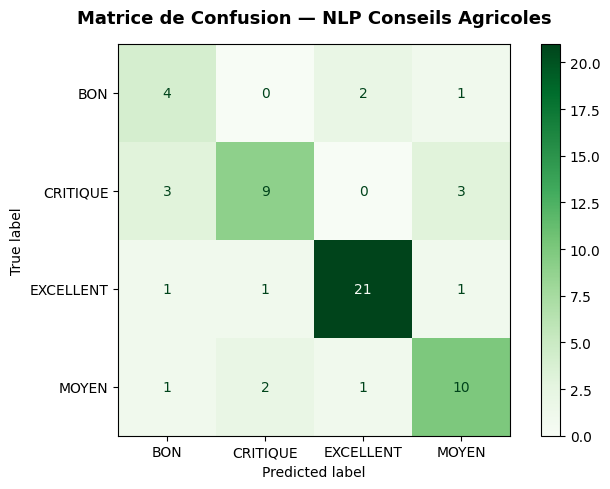

✓ Sauvegardée dans processed/nlp_confusion_matrix.png


In [9]:
# ── Matrice de confusion ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, colorbar=True, cmap='Greens')
ax.set_title('Matrice de Confusion — NLP Conseils Agricoles', 
             fontsize=13, pad=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../processed/nlp_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Sauvegardée dans processed/nlp_confusion_matrix.png")

Cross-validation 5-fold:
  Fold 1: 73.3%
  Fold 2: 73.3%
  Fold 3: 76.7%
  Fold 4: 78.3%
  Fold 5: 70.0%

  Moyenne : 74.3% ± 2.9%


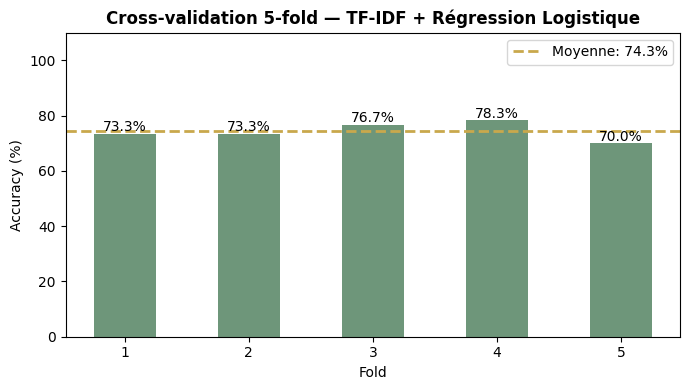

In [10]:
# ── Cross-validation 5-fold ──────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline_nlp, X, y, cv=cv, scoring='accuracy')

print("Cross-validation 5-fold:")
for i, s in enumerate(scores, 1):
    print(f"  Fold {i}: {s*100:.1f}%")
print(f"\n  Moyenne : {scores.mean()*100:.1f}% ± {scores.std()*100:.1f}%")

# Plot CV scores
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(range(1, 6), scores * 100, color='#4a7c59', alpha=0.8, width=0.5)
ax.axhline(scores.mean() * 100, color='#c9a84c', linewidth=2, 
           linestyle='--', label=f'Moyenne: {scores.mean()*100:.1f}%')
ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Cross-validation 5-fold — TF-IDF + Régression Logistique', fontweight='bold')
ax.set_ylim(0, 110); ax.legend()
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{score*100:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../processed/nlp_cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()

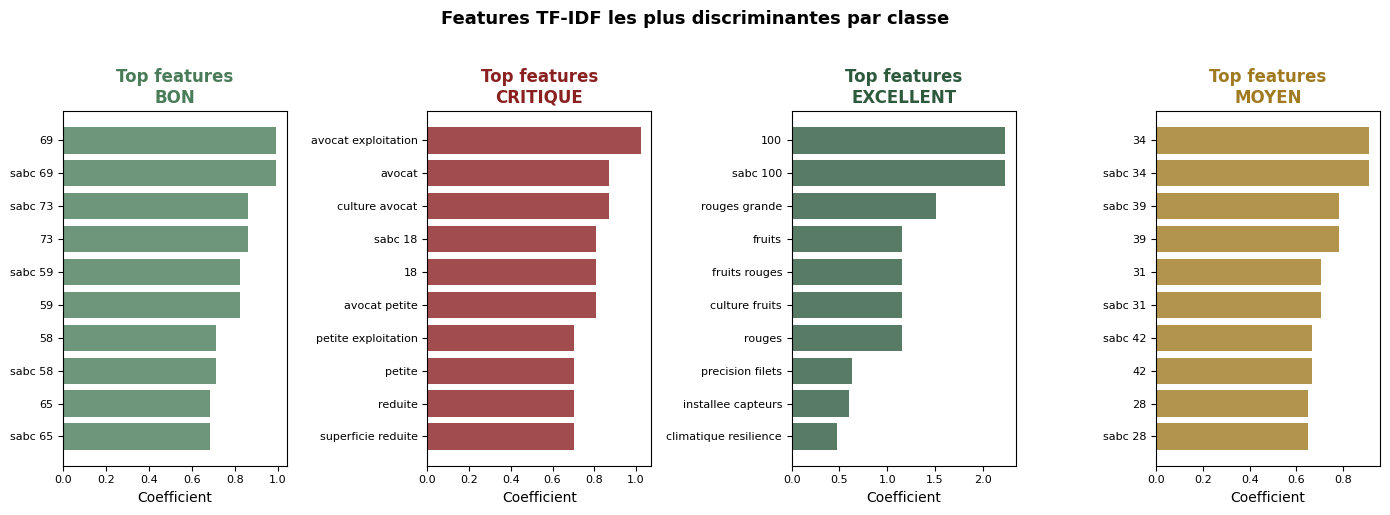

In [11]:
# ── Top features TF-IDF par classe ──────────────────────────────────────────
tfidf   = pipeline_nlp.named_steps['tfidf']
clf     = pipeline_nlp.named_steps['clf']
feature_names = tfidf.get_feature_names_out()
classes = clf.classes_

fig, axes = plt.subplots(1, len(classes), figsize=(14, 5))
colors = {'CRITIQUE': '#8b2020', 'MOYEN': '#a07a20', 
          'BON': '#4a7c59', 'EXCELLENT': '#2d5a3d'}

for ax, cls in zip(axes, classes):
    coefs = clf.coef_[list(classes).index(cls)]
    top_idx = np.argsort(coefs)[-10:]
    top_features = [feature_names[i] for i in top_idx]
    top_coefs    = coefs[top_idx]
    ax.barh(top_features, top_coefs, color=colors.get(cls, '#4a7c59'), alpha=0.8)
    ax.set_title(f'Top features\n{cls}', fontweight='bold', color=colors.get(cls, '#4a7c59'))
    ax.set_xlabel('Coefficient')
    ax.tick_params(labelsize=8)

plt.suptitle('Features TF-IDF les plus discriminantes par classe', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../processed/nlp_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Génération de Texte — Conseils Personnalisés
On combine la **classification** (quelle catégorie ?) avec des **templates enrichis**
qui utilisent les données spécifiques de l'agriculteur pour un texte vraiment personnalisé.

In [12]:
# ── Templates de conseils par catégorie ──────────────────────────────────────
TEMPLATES_CONSEILS = {
    'CRITIQUE': [
        "⚠️ Votre score SABC de {sabc}/100 indique un profil à risque élevé.",
        "Votre exploitation de {ha} ha en {culture} dans la région de {localisation} "
        "présente une résilience très faible (Γ = {gamma:.2f}/1.0).",
        "Priorité absolue : {equipements_manquants}. "
        "L'installation des filets anti-grêle et de l'irrigation de précision "
        "permettrait de faire passer votre score Γ de {gamma:.2f} à {gamma_potentiel:.2f}, "
        "soit un gain SABC estimé de +{gain_sabc:.0f} points.",
        "Le risque climatique de votre zone ({risque:.2f}) amplifie votre vulnérabilité. "
        "Un programme d'équipement progressif sur 2 ans est fortement recommandé "
        "avant de solliciter un crédit agricole."
    ],
    'MOYEN': [
        "📊 Votre score SABC de {sabc}/100 est en-dessous du seuil d'approbation.",
        "Votre exploitation {culture} de {ha} ha ({localisation}) montre "
        "des bases solides mais une résilience encore insuffisante (Γ = {gamma:.2f}/1.0).",
        "Actions prioritaires pour franchir le seuil : {equipements_manquants}. "
        "Ces investissements porteraient votre Γ à {gamma_potentiel:.2f} "
        "et amélioreraient significativement votre score.",
        "Avec votre rendement prédit de {rendement:.0f} kg/ha et un prix de marché "
        "favorable, l'investissement en équipements serait rentabilisé rapidement. "
        "Envisagez une demande de crédit conditionnel pour financer ces améliorations."
    ],
    'BON': [
        "✅ Votre score SABC de {sabc}/100 est encourageant.",
        "Votre exploitation {culture} ({ha} ha, {localisation}) bénéficie "
        "d'une bonne résilience technologique (Γ = {gamma:.2f}/1.0).",
        "{conseils_optimisation} "
        "Ces ajustements permettraient d'optimiser votre production "
        "actuelle de {production:,.0f} kg.",
        "Votre profil est éligible à un crédit conditionnel. "
        "Consolidez vos équipements restants pour viser l'approbation complète."
    ],
    'EXCELLENT': [
        "🏆 Excellent ! Votre score SABC de {sabc}/100 reflète un profil optimal.",
        "Votre exploitation {culture} de {ha} ha dans la région de {localisation} "
        "est parfaitement équipée (Γ = {gamma:.2f}/1.0). "
        "Votre production estimée de {production:,.0f} kg au prix de {prix:.1f} MAD/kg "
        "représente un revenu brut solide.",
        "Pour maintenir ce niveau d'excellence : "
        "surveillez les indicateurs VPD et NDWI de votre région, "
        "renouvelez régulièrement vos certifications d'équipements, "
        "et explorez les opportunités d'export direct.",
        "Votre dossier de crédit agricole est solide. "
        "Nous recommandons une approbation avec les meilleures conditions de taux."
    ]
}

print("✓ Templates chargés — 4 catégories × ~4 paragraphes")
for cat, templates in TEMPLATES_CONSEILS.items():
    print(f"  {cat}: {len(templates)} paragraphes")

✓ Templates chargés — 4 catégories × ~4 paragraphes
  CRITIQUE: 4 paragraphes
  MOYEN: 4 paragraphes
  BON: 4 paragraphes
  EXCELLENT: 4 paragraphes


In [13]:
# ── Fonction de génération de conseil ────────────────────────────────────────
def generer_conseil(profil: dict) -> dict:
    """
    Génère un conseil personnalisé pour un profil agriculteur.
    
    Input  : dict avec les champs du formulaire Flask
    Output : dict avec 'categorie' (str) et 'conseil' (str)
    """
    # 1. Convertir en texte
    # Reconstruire une ligne compatible avec profil_to_text
    row_mock = {
        'Culture':          profil.get('culture', 'Avocat'),
        'Superficie_ha':    profil.get('hectares', 5),
        'Localisation':     profil.get('localisation', 'Agadir'),
        'Type_Sol':         profil.get('sol', 'Argileux'),
        'Annees_Experience': profil.get('annees_experience', 10),
        'Irrigation':       profil.get('irrigation', 0),
        'Solaire':          profil.get('solaire', 0),
        'IoT_sondes':       profil.get('iot', 0),
        'Filets_Serres':    profil.get('filets', 0),
        'Gamma':            profil.get('gamma', 0),
        'Risque_brut':      profil.get('risque_brut', 1.3),
        'SABC_score':       profil.get('sabc', 50),
    }
    texte = profil_to_text(pd.Series(row_mock))
    
    # 2. Classifier
    categorie = pipeline_nlp.predict([texte])[0]
    proba     = pipeline_nlp.predict_proba([texte])[0]
    classes   = pipeline_nlp.classes_
    proba_dict = {c: round(float(p)*100, 1) for c, p in zip(classes, proba)}
    
    # 3. Préparer les variables du template
    culture   = profil.get('culture', 'Avocat').replace('_', ' ')
    ha        = profil.get('hectares', 5)
    loc       = profil.get('localisation', '')
    gamma     = profil.get('gamma', 0)
    sabc      = profil.get('sabc', 0)
    risque    = profil.get('risque_brut', 1.3)
    rendement = profil.get('rendement', 9000)
    production= profil.get('production', 0)
    prix      = profil.get('prix_kg', 30)
    
    # Équipements manquants
    manquants = []
    if not profil.get('irrigation'):  manquants.append("irrigation de précision (Γ+0.25)")
    if not profil.get('solaire'):     manquants.append("énergie solaire (Γ+0.15)")
    if not profil.get('iot'):         manquants.append("capteurs IoT (Γ+0.20)")
    if not profil.get('filets'):      manquants.append("filets anti-grêle (Γ+0.40)")
    
    manquants_txt = ", ".join(manquants) if manquants else "aucun — profil complet"
    
    # Gamma potentiel (si tous les équipements installés)
    gamma_pot = min(1.0, gamma + sum([
        0.25 if not profil.get('irrigation') else 0,
        0.15 if not profil.get('solaire')    else 0,
        0.20 if not profil.get('iot')        else 0,
        0.40 if not profil.get('filets')     else 0,
    ]))
    gain_sabc = max(0, min(100, sabc * (1 - gamma + 0.01) / (1 - gamma_pot + 0.01)) - sabc)
    
    # Conseils d'optimisation pour profil BON
    conseils_opt = []
    if rendement < 9000:  conseils_opt.append("Optimisez la fertilisation pour améliorer le rendement.")
    if risque > 1.3:      conseils_opt.append("Renforcez la protection climatique.")
    conseils_opt_txt = " ".join(conseils_opt) if conseils_opt else "Continuez sur cette lancée."
    
    vars_template = {
        'sabc': sabc, 'ha': ha, 'culture': culture,
        'localisation': loc, 'gamma': gamma,
        'gamma_potentiel': gamma_pot, 'gain_sabc': gain_sabc,
        'risque': risque, 'rendement': rendement,
        'production': production, 'prix': prix,
        'equipements_manquants': manquants_txt,
        'conseils_optimisation': conseils_opt_txt,
    }
    
    # 4. Générer le texte
    templates = TEMPLATES_CONSEILS.get(categorie, TEMPLATES_CONSEILS['MOYEN'])
    paragraphes = []
    for tpl in templates:
        try:
            paragraphes.append(tpl.format(**vars_template))
        except KeyError:
            paragraphes.append(tpl)
    
    conseil_txt = "\n\n".join(paragraphes)
    
    return {
        'categorie':  categorie,
        'conseil':    conseil_txt,
        'probabilites': proba_dict,
        'confiance':  round(max(proba) * 100, 1)
    }

print("✓ Fonction generer_conseil() prête")

✓ Fonction generer_conseil() prête


## 7. Tests sur Exemples Réels

In [14]:
# ── Test 1 — Profil CRITIQUE ─────────────────────────────────────────────────
profil_critique = {
    'culture': 'Avocat', 'hectares': 2.0, 'localisation': 'Agadir',
    'sol': 'Sableux', 'irrigation': 0, 'solaire': 0, 'iot': 0, 'filets': 0,
    'gamma': 0.0, 'sabc': 12.5, 'risque_brut': 1.6,
    'rendement': 5200, 'production': 10400, 'prix_kg': 28.0
}
res = generer_conseil(profil_critique)
print(f"CATÉGORIE PRÉDITE : {res['categorie']} (confiance: {res['confiance']}%)")
print(f"Probabilités : {res['probabilites']}")
print("\n" + "─"*60)
print(res['conseil'])

CATÉGORIE PRÉDITE : CRITIQUE (confiance: 85.3%)
Probabilités : {'BON': 7.2, 'CRITIQUE': 85.3, 'EXCELLENT': 1.9, 'MOYEN': 5.6}

────────────────────────────────────────────────────────────
⚠️ Votre score SABC de 12.5/100 indique un profil à risque élevé.

Votre exploitation de 2.0 ha en Avocat dans la région de Agadir présente une résilience très faible (Γ = 0.00/1.0).

Priorité absolue : irrigation de précision (Γ+0.25), énergie solaire (Γ+0.15), capteurs IoT (Γ+0.20), filets anti-grêle (Γ+0.40). L'installation des filets anti-grêle et de l'irrigation de précision permettrait de faire passer votre score Γ de 0.00 à 1.00, soit un gain SABC estimé de +88 points.

Le risque climatique de votre zone (1.60) amplifie votre vulnérabilité. Un programme d'équipement progressif sur 2 ans est fortement recommandé avant de solliciter un crédit agricole.


In [15]:
# ── Test 2 — Profil EXCELLENT ────────────────────────────────────────────────
profil_excellent = {
    'culture': 'Fruits_Rouges', 'hectares': 10.0, 'localisation': 'Kenitra',
    'sol': 'Limoneux', 'irrigation': 1, 'solaire': 1, 'iot': 3, 'filets': 1,
    'gamma': 1.0, 'sabc': 95.0, 'risque_brut': 1.1,
    'rendement': 14000, 'production': 140000, 'prix_kg': 58.0
}
res = generer_conseil(profil_excellent)
print(f"CATÉGORIE PRÉDITE : {res['categorie']} (confiance: {res['confiance']}%)")
print("\n" + "─"*60)
print(res['conseil'])

CATÉGORIE PRÉDITE : EXCELLENT (confiance: 79.6%)

────────────────────────────────────────────────────────────
🏆 Excellent ! Votre score SABC de 95.0/100 reflète un profil optimal.

Votre exploitation Fruits Rouges de 10.0 ha dans la région de Kenitra est parfaitement équipée (Γ = 1.00/1.0). Votre production estimée de 140,000 kg au prix de 58.0 MAD/kg représente un revenu brut solide.

Pour maintenir ce niveau d'excellence : surveillez les indicateurs VPD et NDWI de votre région, renouvelez régulièrement vos certifications d'équipements, et explorez les opportunités d'export direct.

Votre dossier de crédit agricole est solide. Nous recommandons une approbation avec les meilleures conditions de taux.


In [16]:
# ── Test 3 — Profil MOYEN ───────────────────────────────────────────────────
profil_moyen = {
    'culture': 'Avocat', 'hectares': 5.0, 'localisation': 'Marrakech',
    'sol': 'Argileux', 'irrigation': 1, 'solaire': 0, 'iot': 0, 'filets': 0,
    'gamma': 0.25, 'sabc': 38.0, 'risque_brut': 1.4,
    'rendement': 8000, 'production': 40000, 'prix_kg': 30.0
}
res = generer_conseil(profil_moyen)
print(f"CATÉGORIE PRÉDITE : {res['categorie']} (confiance: {res['confiance']}%)")
print("\n" + "─"*60)
print(res['conseil'])

CATÉGORIE PRÉDITE : CRITIQUE (confiance: 54.1%)

────────────────────────────────────────────────────────────
⚠️ Votre score SABC de 38.0/100 indique un profil à risque élevé.

Votre exploitation de 5.0 ha en Avocat dans la région de Marrakech présente une résilience très faible (Γ = 0.25/1.0).

Priorité absolue : énergie solaire (Γ+0.15), capteurs IoT (Γ+0.20), filets anti-grêle (Γ+0.40). L'installation des filets anti-grêle et de l'irrigation de précision permettrait de faire passer votre score Γ de 0.25 à 1.00, soit un gain SABC estimé de +62 points.

Le risque climatique de votre zone (1.40) amplifie votre vulnérabilité. Un programme d'équipement progressif sur 2 ans est fortement recommandé avant de solliciter un crédit agricole.


## 8. Évaluation du Pipeline Complet (Classification + Génération)

In [17]:
# ── Test sur tout le test set ────────────────────────────────────────────────
resultats = []
for _, row in ag.iloc[X_test.index].iterrows():
    profil = {
        'culture':      row['Culture'],
        'hectares':     row['Superficie_ha'],
        'localisation': row['Localisation'],
        'sol':          row['Type_Sol'],
        'irrigation':   row['Irrigation'],
        'solaire':      row['Solaire'],
        'iot':          row['IoT_sondes'],
        'filets':       row['Filets_Serres'],
        'gamma':        row['Gamma'],
        'sabc':         row['SABC_score'],
        'risque_brut':  row['Risque_brut'],
        'rendement':    row['Rendement_kg_ha'],
        'production':   row['Production_totale_kg'],
        'prix_kg':      row['Prix_vente_MAD_kg'],
    }
    res = generer_conseil(profil)
    resultats.append({
        'vrai_label':    row['label_conseil'],
        'pred_label':    res['categorie'],
        'confiance':     res['confiance'],
        'longueur_texte': len(res['conseil'])
    })

df_eval = pd.DataFrame(resultats)
print(f"Accuracy pipeline complet : {(df_eval['vrai_label'] == df_eval['pred_label']).mean()*100:.1f}%")
print(f"Confiance moyenne         : {df_eval['confiance'].mean():.1f}%")
print(f"Longueur moyenne du texte : {df_eval['longueur_texte'].mean():.0f} caractères")
print()
print("Distribution des prédictions:")
print(df_eval['pred_label'].value_counts())

Accuracy pipeline complet : 76.7%
Confiance moyenne         : 52.9%
Longueur moyenne du texte : 594 caractères

Distribution des prédictions:
pred_label
EXCELLENT    25
MOYEN        16
CRITIQUE     13
BON           6
Name: count, dtype: int64


## 9. Sauvegarde des Modèles

In [18]:
# ── Sauvegarde ───────────────────────────────────────────────────────────────
# 1. Pipeline TF-IDF + Logistic Regression
joblib.dump(pipeline_nlp, os.path.join(MODEL_PATH, 'nlp_pipeline.pkl'))
print("✓ nlp_pipeline.pkl sauvegardé")

# 2. Templates de conseils (JSON)
with open(os.path.join(MODEL_PATH, 'nlp_templates.json'), 'w', encoding='utf-8') as f:
    json.dump(TEMPLATES_CONSEILS, f, ensure_ascii=False, indent=2)
print("✓ nlp_templates.json sauvegardé")

# 3. Métadonnées du modèle
metadata = {
    'accuracy_test':     float(accuracy_score(y_test, y_pred)),
    'cv_mean':           float(scores.mean()),
    'cv_std':            float(scores.std()),
    'classes':           list(pipeline_nlp.classes_),
    'n_features_tfidf':  len(tfidf.get_feature_names_out()),
    'ngram_range':       '(1,2)',
    'train_size':        len(X_train),
    'test_size':         len(X_test),
}
with open(os.path.join(MODEL_PATH, 'nlp_metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print("✓ nlp_metadata.json sauvegardé")

print()
print("=== FICHIERS SAUVEGARDÉS ===")
for f in ['nlp_pipeline.pkl', 'nlp_templates.json', 'nlp_metadata.json']:
    path = os.path.join(MODEL_PATH, f)
    size = os.path.getsize(path)
    print(f"  {f} ({size/1024:.1f} KB)")

✓ nlp_pipeline.pkl sauvegardé
✓ nlp_templates.json sauvegardé
✓ nlp_metadata.json sauvegardé

=== FICHIERS SAUVEGARDÉS ===
  nlp_pipeline.pkl (21.5 KB)
  nlp_templates.json (2.5 KB)
  nlp_metadata.json (0.3 KB)


In [19]:
# ── Vérification : rechargement et test ──────────────────────────────────────
pipeline_reloaded = joblib.load(os.path.join(MODEL_PATH, 'nlp_pipeline.pkl'))
with open(os.path.join(MODEL_PATH, 'nlp_templates.json'), 'r', encoding='utf-8') as f:
    templates_reloaded = json.load(f)

test_pred = pipeline_reloaded.predict(["culture avocat irrigation precision installee resilience excellente score sabc 90"])
print(f"✓ Pipeline rechargé — test prédiction : {test_pred[0]}")
print(f"✓ Templates rechargés — {len(templates_reloaded)} catégories")
print()
print("╔══════════════════════════════════════════╗")
print("║  NLP PIPELINE PRÊT POUR FLASK            ║")
print("║  → models/nlp_pipeline.pkl               ║")
print("║  → models/nlp_templates.json             ║")
print("╚══════════════════════════════════════════╝")

✓ Pipeline rechargé — test prédiction : BON
✓ Templates rechargés — 4 catégories

╔══════════════════════════════════════════╗
║  NLP PIPELINE PRÊT POUR FLASK            ║
║  → models/nlp_pipeline.pkl               ║
║  → models/nlp_templates.json             ║
╚══════════════════════════════════════════╝


## 10. Résumé du Mini-Projet NLP

| Étape | Détail |
|-------|--------|
| **Données** | 300 profils agriculteurs → textes générés |
| **Modèle** | TF-IDF (1-2 grams, 500 features) + Régression Logistique |
| **Classes** | CRITIQUE / MOYEN / BON / EXCELLENT |
| **Split** | 80% train / 20% test (stratifié) |
| **CV** | 5-fold StratifiedKFold |
| **Génération** | Templates enrichis par classe |
| **Output** | `nlp_pipeline.pkl` + `nlp_templates.json` |

### Intégration Flask
Les modèles sont appelés dans `App.py` via la route `/conseil` → affichage dans `resultat.html`
